In [2]:
!pip install ultralytics

from ultralytics import YOLO
import os, shutil, random


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
dataset_path = "/content/drive/MyDrive/adl_project/Dataset_BUSI_with_GT"
base_dir = "datasets/busi_class"
os.makedirs(f"{base_dir}/train/benign", exist_ok=True)
os.makedirs(f"{base_dir}/train/malignant", exist_ok=True)
os.makedirs(f"{base_dir}/val/benign", exist_ok=True)
os.makedirs(f"{base_dir}/val/malignant", exist_ok=True)

In [5]:
#split data
for label in ["benign", "malignant"]:
    files = os.listdir(os.path.join(dataset_path, label))
    random.shuffle(files)
    split = int(0.8 * len(files))
    train_files = files[:split]
    val_files = files[split:]

    for f in train_files:
        shutil.copy(os.path.join(dataset_path, label, f), f"{base_dir}/train/{label}/{f}")
    for f in val_files:
        shutil.copy(os.path.join(dataset_path, label, f), f"{base_dir}/val/{label}/{f}")

print("Dataset split done!")


Dataset split done!


In [6]:
model = YOLO("yolov8n-cls.pt")
results = model.train(
    data="datasets/busi_class",
    epochs=5,
    imgsz=224,
    batch=16
)

Ultralytics 8.3.205 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/busi_class, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, 

In [7]:
model.val()

Ultralytics 8.3.205 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,437,442 parameters, 0 gradients, 3.3 GFLOPs
train: /content/datasets/busi_class/train... found 1048 images in 2 classes ✅ 
val: /content/datasets/busi_class/val... found 264 images in 2 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 860.0±1424.3 MB/s, size: 151.2 KB)
val: Scanning /content/datasets/busi_class/val... 264 images, 0 corrupt: 100% ━━━━━━━━━━━━ 264/264 552.0Kit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 17/17 7.1it/s 2.4s
                   all      0.924          1
Speed: 0.2ms preprocess, 1.4ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val


ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c062a52f050>
curves: []
curves_results: []
fitness: 0.9621212184429169
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9242424368858337, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9621212184429169}
save_dir: PosixPath('/content/runs/classify/val')
speed: {'preprocess': 0.23613031439398666, 'inference': 1.3999105530303244, 'loss': 0.0009042803029477441, 'postprocess': 0.001233606060722967}
task: 'classify'
top1: 0.9242424368858337
top5: 1.0

In [11]:
model.predict(source="/content/runs/classify/val", save=True)


image 1/8 /content/runs/classify/val/confusion_matrix.png: 224x224 benign 0.92, malignant 0.08, 2.7ms
image 2/8 /content/runs/classify/val/confusion_matrix_normalized.png: 224x224 benign 0.95, malignant 0.05, 4.3ms
image 3/8 /content/runs/classify/val/val_batch0_labels.jpg: 224x224 benign 0.97, malignant 0.03, 2.7ms
image 4/8 /content/runs/classify/val/val_batch0_pred.jpg: 224x224 benign 0.95, malignant 0.05, 3.6ms
image 5/8 /content/runs/classify/val/val_batch1_labels.jpg: 224x224 benign 0.98, malignant 0.02, 2.4ms
image 6/8 /content/runs/classify/val/val_batch1_pred.jpg: 224x224 benign 0.98, malignant 0.02, 3.1ms
image 7/8 /content/runs/classify/val/val_batch2_labels.jpg: 224x224 benign 0.97, malignant 0.03, 2.9ms
image 8/8 /content/runs/classify/val/val_batch2_pred.jpg: 224x224 benign 0.97, malignant 0.03, 2.9ms
Speed: 18.7ms preprocess, 3.1ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Results saved to /content/runs/classify/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: None
 keypoints: None
 masks: None
 names: {0: 'benign', 1: 'malignant'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [2

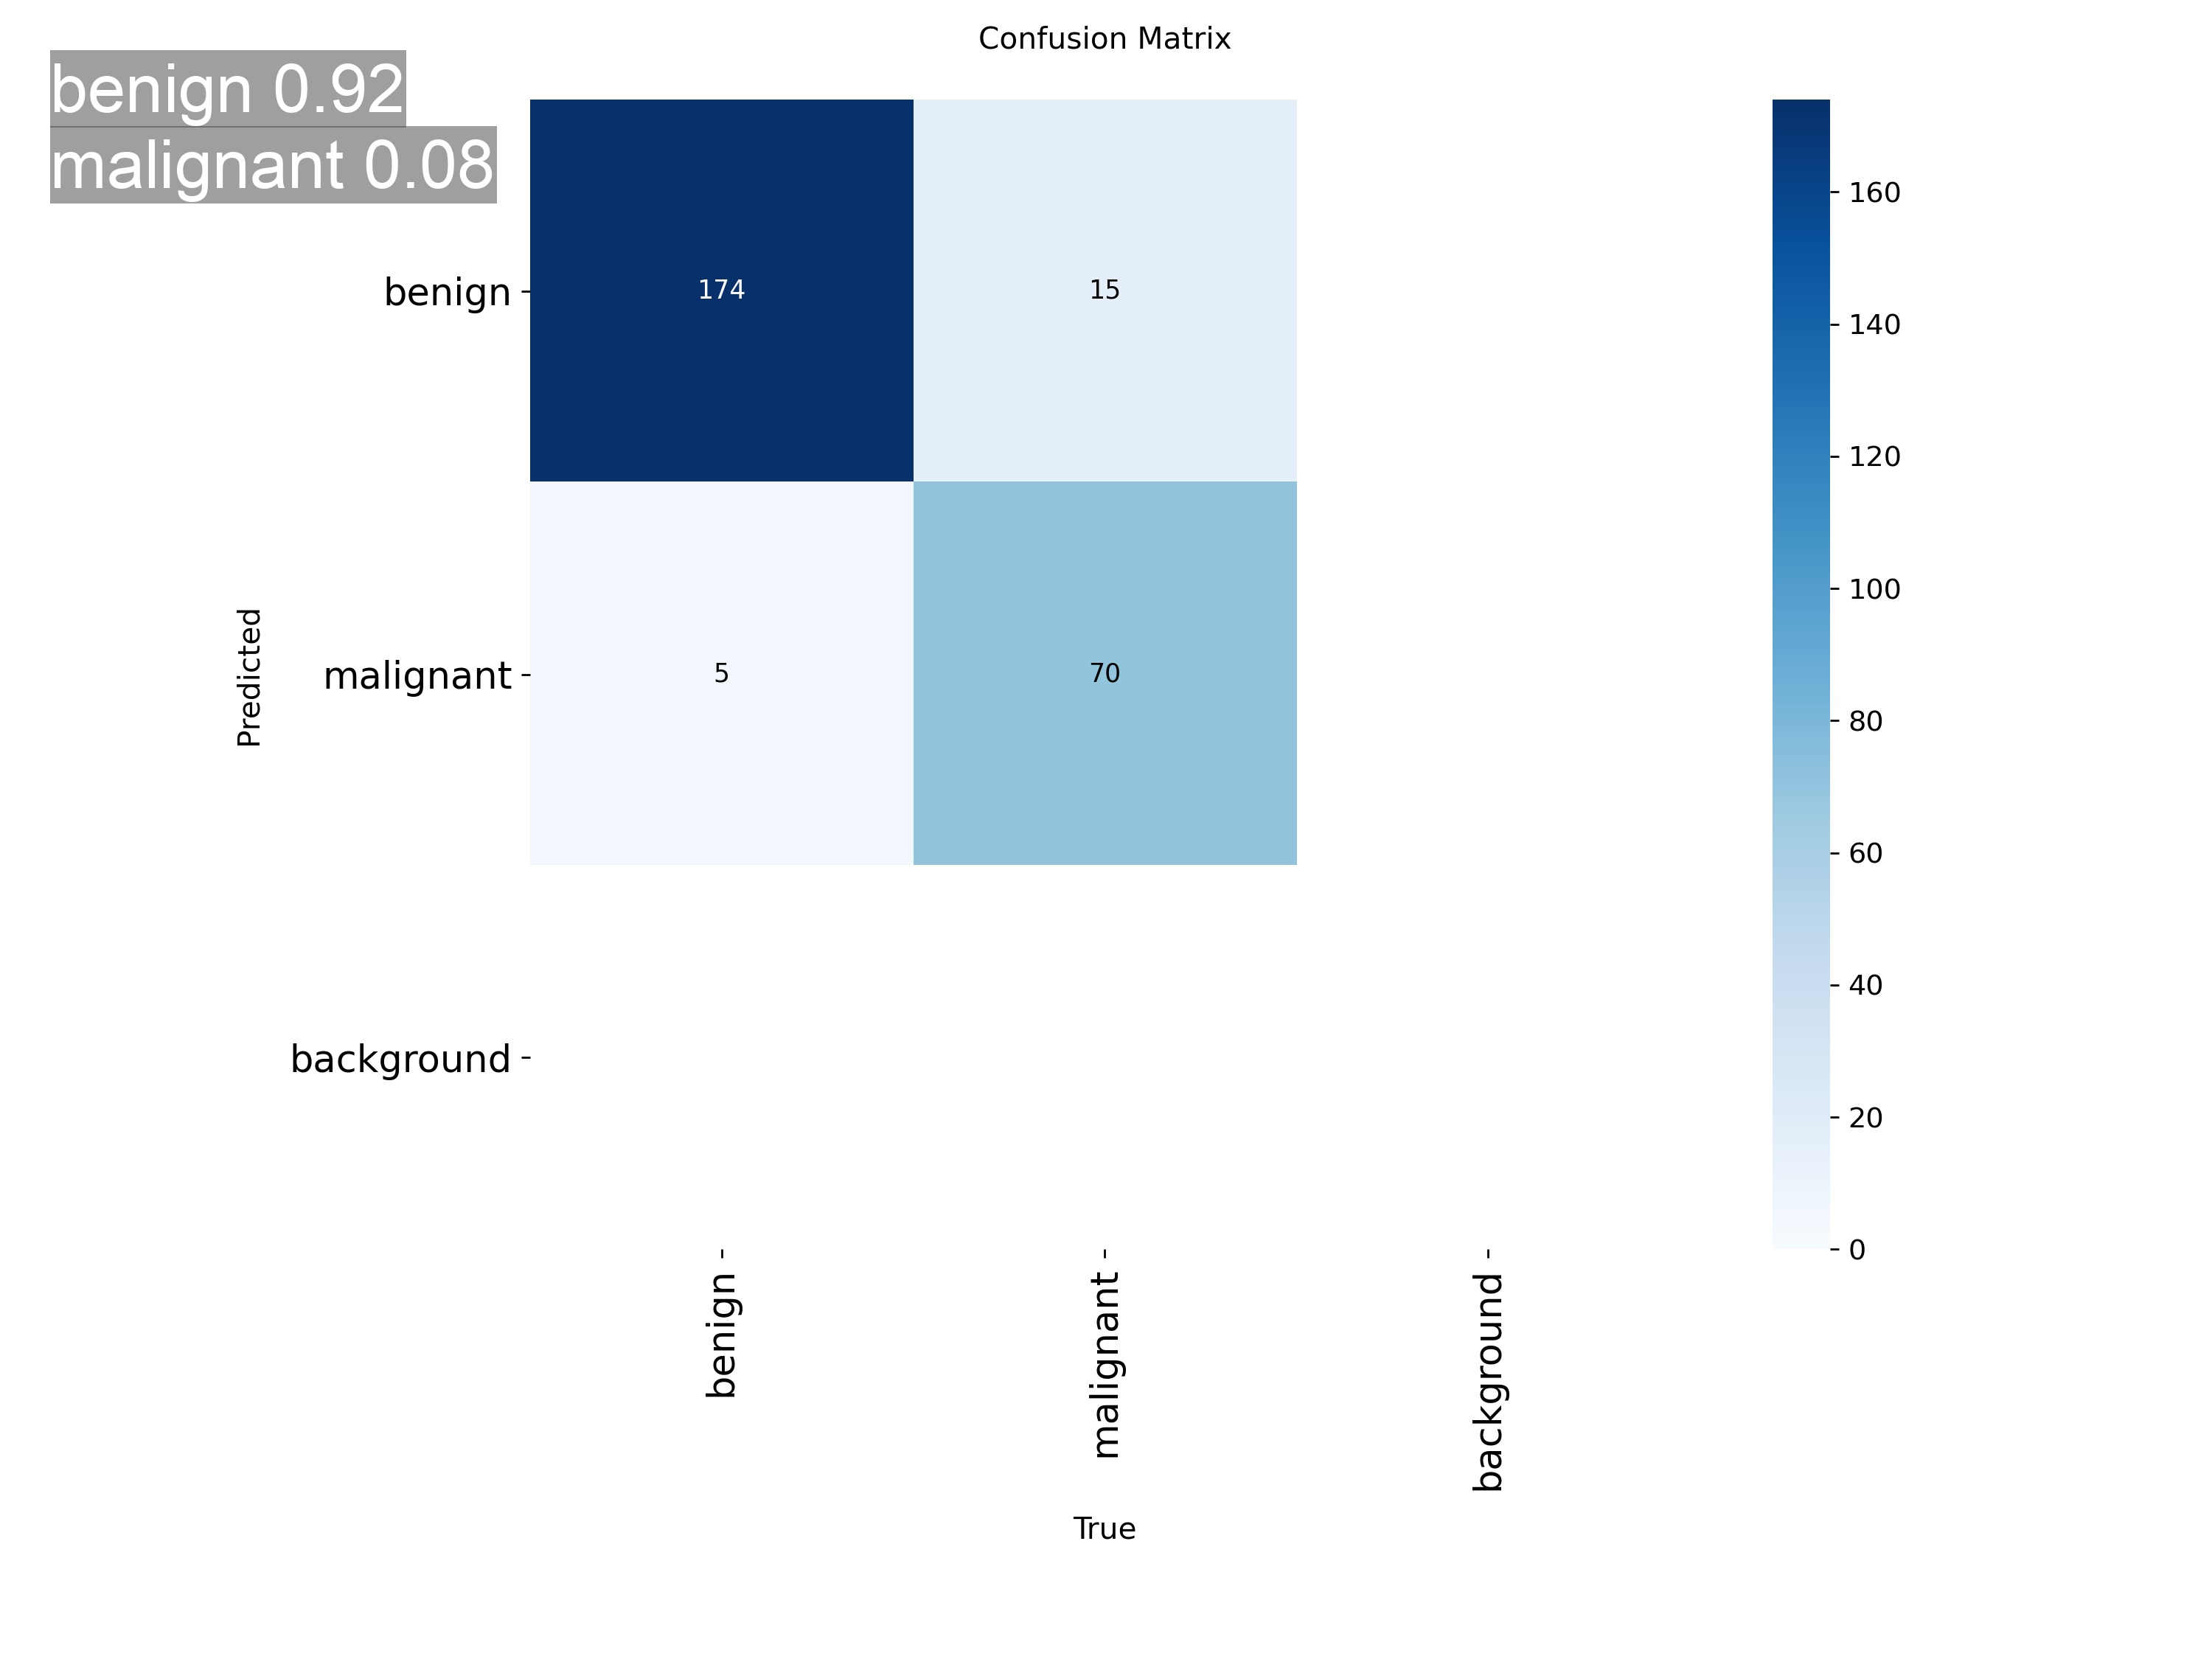

In [13]:
import glob
from IPython.display import Image, display

for img_path in glob.glob("runs/classify/predict/*.jpg")[:1]:
    display(Image(filename=img_path))


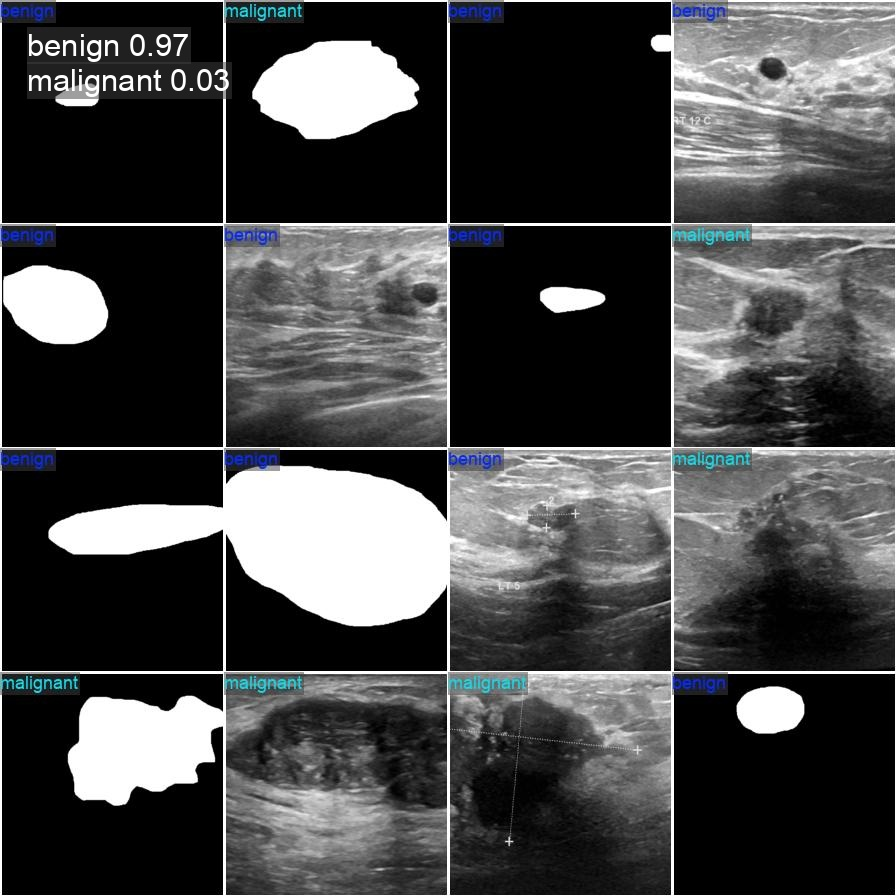

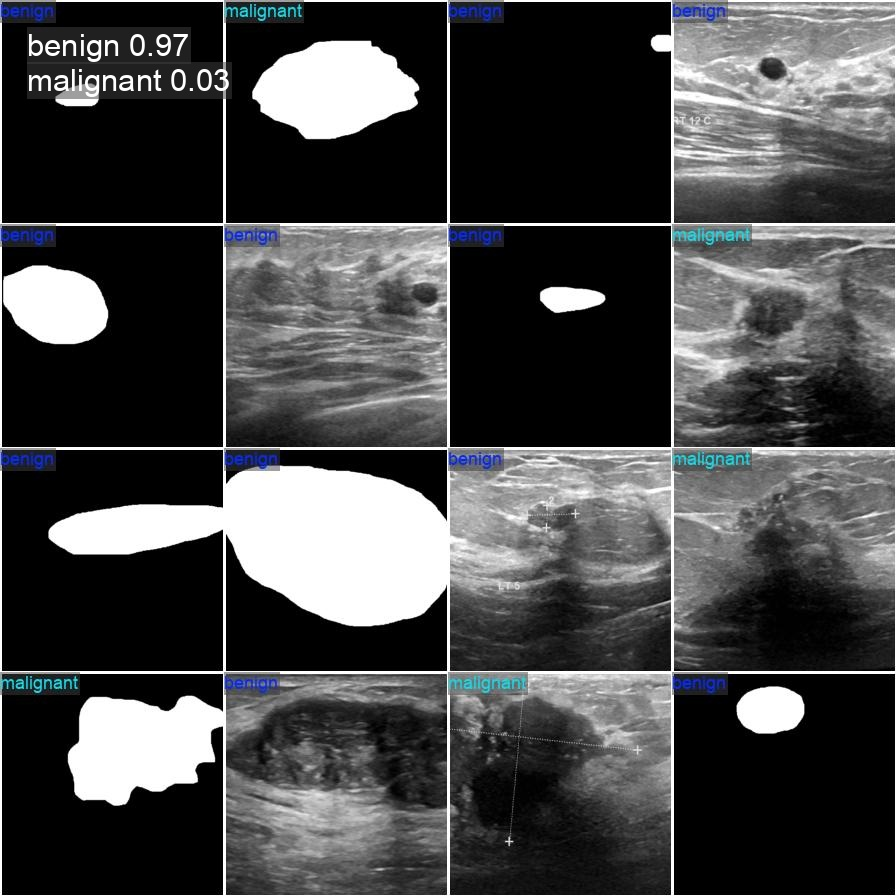

In [16]:
import glob
from IPython.display import Image, display

for img_path in glob.glob("runs/classify/predict/*.jpg")[1:3]:
    display(Image(filename=img_path))


In [20]:
from ultralytics import YOLO
import numpy as np

model = YOLO("/content/runs/classify/train2/weights/best.pt")
metrics = model.val()
print(metrics)  # prints accuracy, precision, recall, F1-score, etc.


Ultralytics 8.3.205 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,437,442 parameters, 0 gradients, 3.3 GFLOPs
train: /content/datasets/busi_class/train... found 1048 images in 2 classes ✅ 
val: /content/datasets/busi_class/val... found 264 images in 2 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1553.7±2163.5 MB/s, size: 151.2 KB)
val: Scanning /content/datasets/busi_class/val... 264 images, 0 corrupt: 100% ━━━━━━━━━━━━ 264/264 497.2Kit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 17/17 8.0it/s 2.1s
                   all      0.924          1
Speed: 0.3ms preprocess, 0.8ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val4
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c062b6bf590>
curves: []
curves_results: []
fitness: 0.9621212184429